# Cross analysis of two time series

This notebook demonstrates the four cross-analysis routines in
`nolitisea.cross`.  Each one compares **two** time series to measure
synchronisation, lagged dependence, shared geometry or cross-predictability:

| # | Routine | Measures | Returns |
|---|---------|----------|---------|
| 1 | `xcor.cross_correlation` | linear lagged correlation | correlation curve over lags |
| 2 | `xc2.cross_correlation_integral` | cross-correlation integral over radii | pair-count curves per embedding order |
| 3 | `xrecur.cross_recurrence` | cross-recurrence points | `(row, col)` index pairs |
| 4 | `xzero.cross_zeroth` | zeroth-order cross-prediction error | forecast error vs horizon |

We use Hénon-map trajectories as running examples; two orbits of the same
system share the same attractor (so cross-structure should be strong), while
white noise shares none (so the cross-statistics should vanish / saturate).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.cross.xc2 import cross_correlation_integral
from nolitisea.cross.xcor import cross_correlation
from nolitisea.cross.xrecur import cross_recurrence
from nolitisea.cross.xzero import cross_zeroth
from nolitisea.generate.henon import henon

np.random.seed(42)

# Two independent Hénon orbits (different transients / initial conditions).
x1, _ = henon(n=4000, discard=500)
x2, _ = henon(n=4000, discard=1500)
print(f"series 1: shape {x1.shape}, range [{x1.min():.3f}, {x1.max():.3f}]")
print(f"series 2: shape {x2.shape}, range [{x2.min():.3f}, {x2.max():.3f}]")

series 1: shape (4000,), range [-1.285, 1.273]
series 2: shape (4000,), range [-1.284, 1.273]


## 1. `xcor` — linear cross-correlation

`cross_correlation(a, b, max_lag)` computes the normalised linear
cross-correlation of two scalar series over lags `-max_lag .. max_lag`.
The peak lag gives the (linear) time shift between the two series, and the
peak height measures how strongly `b` follows a shifted copy of `a`.

As a sanity check we build a known lagged copy of the first orbit:
`b[n] = a[n - lag]`.  The cross-correlation must peak exactly at `lag`.

In [2]:
lag_true = 7
a = x1[:2000]
b = np.roll(a, lag_true)
b[:lag_true] = a[:lag_true]  # remove the wrapped-around samples

r = cross_correlation(a, b, max_lag=30)
lags = r["lags"]
corr = r["corr"]
peak_lag = int(lags[np.argmax(corr)])
print(f"true lag = {lag_true}, detected peak lag = {peak_lag}")
print(f"peak correlation = {corr.max():.3f}")

true lag = 7, detected peak lag = 7
peak correlation = 1.001


### Correlation curve

The curve peaks sharply at the imposed lag of 7, recovering the known shift
between the two series.

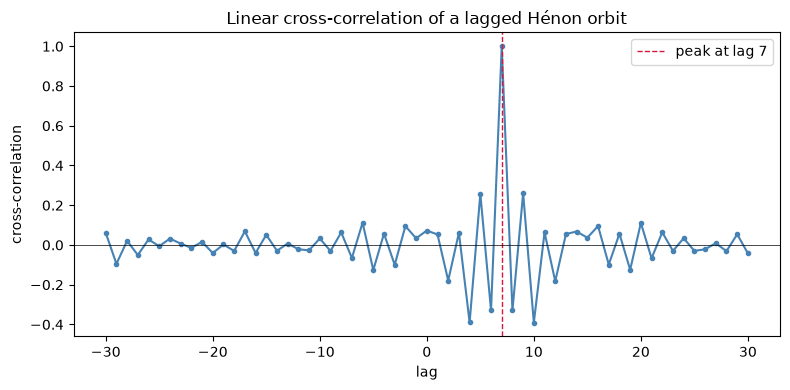

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, corr, "-o", ms=3, color="steelblue")
ax.axvline(peak_lag, color="crimson", ls="--", lw=1,
           label=f"peak at lag {peak_lag}")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag")
ax.set_ylabel("cross-correlation")
ax.set_title("Linear cross-correlation of a lagged Hénon orbit")
ax.legend()
plt.tight_layout()
plt.show()

## 2. `xc2` — cross-correlation integral

`cross_correlation_integral(a, b, embed, delay)` generalises the Grassberger
& Procaccia correlation integral to two series.  Both series are embedded in
the same delay space; for a ladder of neighbourhood radii `eps` it counts the
fraction of cross pairs (a vector from `a`, a vector from `b`) lying within
`eps`, separately for each embedding order.  Two deterministic series drawn
from the same attractor show a steep power-law growth of the integral as the
radius increases.

`c2` returns the radii `eps`, the embedding `orders`, the integral values
`c` (shape `(n_orders, n_eps)`) and the number of reference vectors scanned.

In [4]:
c2 = cross_correlation_integral(x1, x2, embed=4, delay=1)
print("radii (eps):", c2["eps"].shape, "values, descending from",
      f"{c2['eps'][0]:.4f} to {c2['eps'][-1]:.6f}")
print("embedding orders:", c2["orders"])
print("integral array c:", c2["c"].shape)

radii (eps): (203,) values, descending from 2.5601 to 0.000000
embedding orders: [2 3 4]
integral array c: (3, 203)


### Cross-correlation integral vs radius

On a log–log scale the integral grows as a power law in the radius.  Higher
embedding orders sit lower: at a fixed radius, fewer vectors are close in
more coordinates.

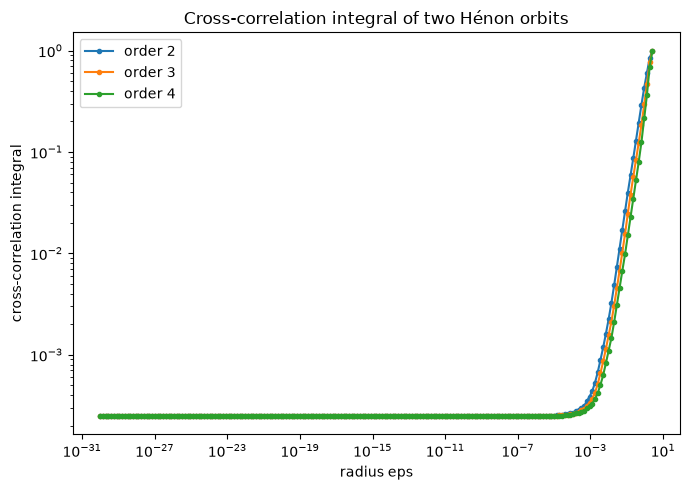

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for k, order in enumerate(c2["orders"]):
    valid = c2["c"][k] > 0
    ax.loglog(c2["eps"][valid], c2["c"][k][valid], "-o", ms=3,
              label=f"order {order}")
ax.set_xlabel("radius eps")
ax.set_ylabel("cross-correlation integral")
ax.set_title("Cross-correlation integral of two Hénon orbits")
ax.legend()
plt.tight_layout()
plt.show()

## 3. `xrecur` — cross-recurrence plot

`cross_recurrence(a, b, dim, delay, eps)` finds every pair of delay vectors
— one from `a` (rows), one from `b` (columns) — whose distance is below the
neighbourhood radius `eps`.  It returns an integer array of `(row, col)`
index pairs, which can be plotted as a cross-recurrence plot: points mark
times at which the two systems visit the same region of the embedded space.

For two orbits of the same deterministic attractor the recurrence points are
dense; the components of both series are first rescaled to `[0, 1]` so that
`eps` is a fraction of the data range.

In [6]:
pairs = cross_recurrence(x1[:1500], x2[:1500], dim=2, delay=1, eps=0.03)
print(f"cross-recurrence pairs: {pairs.shape[0]}")
print("first few (row, col) pairs:")
print(pairs[:5])

cross-recurrence pairs: 54417
first few (row, col) pairs:
[[  0  39]
 [  0  73]
 [  0  82]
 [  0 135]
 [  0 168]]


### Cross-recurrence plot

Each dot marks a recurrence between the `a` orbit (vertical axis) and the
`b` orbit (horizontal axis).  The point cloud reflects the shared Hénon
attractor geometry.

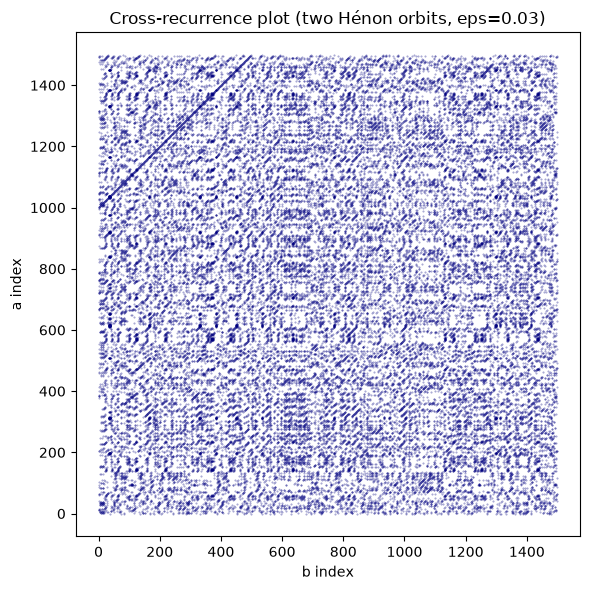

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pairs[:, 1], pairs[:, 0], s=0.2, c="navy", alpha=0.4)
ax.set_xlabel("b index")
ax.set_ylabel("a index")
ax.set_title("Cross-recurrence plot (two Hénon orbits, eps=0.03)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. `xzero` — zeroth-order cross prediction

`cross_zeroth(a, b, dim, delay, n_steps)` tests how well one series can be
forecast from another with a zeroth-order local model: for each delay vector
of `b`, the nearest delay vectors in `a` are found and the mean of their
successors in `a` is used as the forecast of `b`.  The relative rms forecast
error is reported for every horizon `1 .. n_steps`.

An error of **1** means the forecast is no better than predicting the mean;
**0** is a perfect forecast.  Two orbits of the same attractor predict each
other well (small error), while white noise shares no structure (error stays
around or above 1).

In [8]:
steps = 20

# Same dynamics: predict orbit 2 from orbit 1.
res_same = cross_zeroth(x1, x2, dim=3, delay=1, n_steps=steps)

# No common dynamics: predict white noise from the Hénon orbit.
noise = np.random.default_rng(0).standard_normal(x1.size)
res_noise = cross_zeroth(x1, noise, dim=3, delay=1, n_steps=steps)

print("horizon :", res_same["steps"][:6])
print("error (Henon -> Henon):", np.round(res_same["error"][:6], 3))
print("error (Henon -> noise):", np.round(res_noise["error"][:6], 3))

horizon : [1 2 3 4 5 6]
error (Henon -> Henon): [0.028 0.05  0.084 0.146 0.267 0.489]
error (Henon -> noise): [2.283 2.281 2.283 2.056 1.618 1.398]


### Cross-forecast error vs horizon

The same-system error starts well below 1 and grows with the horizon
(predictability is lost over time), whereas the white-noise curve stays near
1 (no shared structure to exploit).

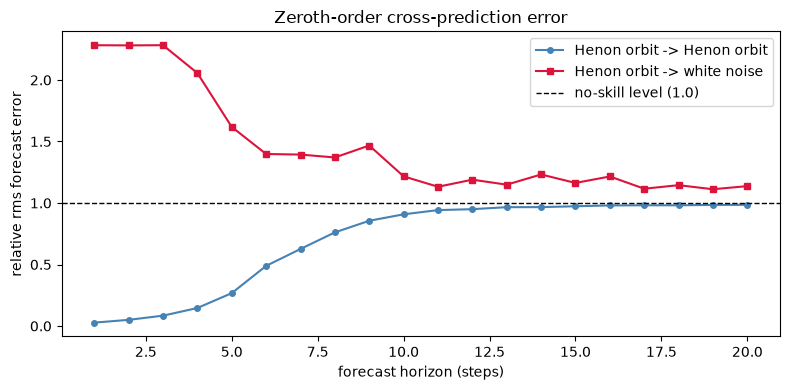

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_same["steps"], res_same["error"], "-o", ms=4,
        color="steelblue", label="Henon orbit -> Henon orbit")
ax.plot(res_noise["steps"], res_noise["error"], "-s", ms=4,
        color="crimson", label="Henon orbit -> white noise")
ax.axhline(1.0, color="k", ls="--", lw=1, label="no-skill level (1.0)")
ax.set_xlabel("forecast horizon (steps)")
ax.set_ylabel("relative rms forecast error")
ax.set_title("Zeroth-order cross-prediction error")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

`nolitisea.cross` offers four complementary ways to compare two time series:

| Routine | Type | Question it answers |
|---------|------|---------------------|
| `cross_correlation` | linear, time-domain | At what lag and how strongly do the series move together linearly? |
| `cross_correlation_integral` | nonlinear, geometric | How densely do embedded vectors of the two series intermingle as a function of radius? |
| `cross_recurrence` | nonlinear, geometric | At which pairs of times do the two systems revisit the same region of state space? |
| `cross_zeroth` | nonlinear, predictive | How well can one series be forecast from the other, and for how many steps? |

`cross_correlation` is fast and picks up linear lagged dependence only; the
three delay-space routines (`xc2`, `xrecur`, `xzero`) capture nonlinear
relationships and all expect a pair of (possibly multivariate) series with
the same embedding geometry.